#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 rows:


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


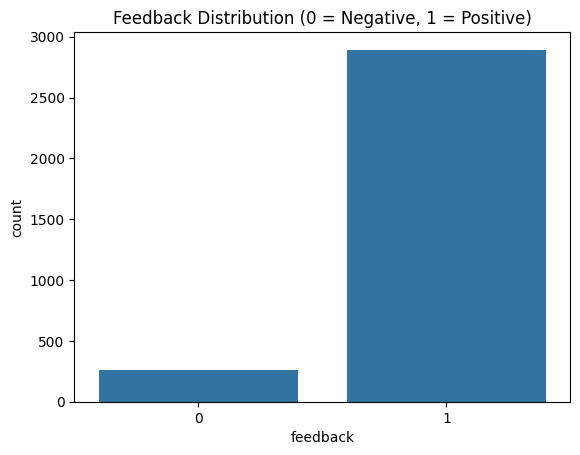

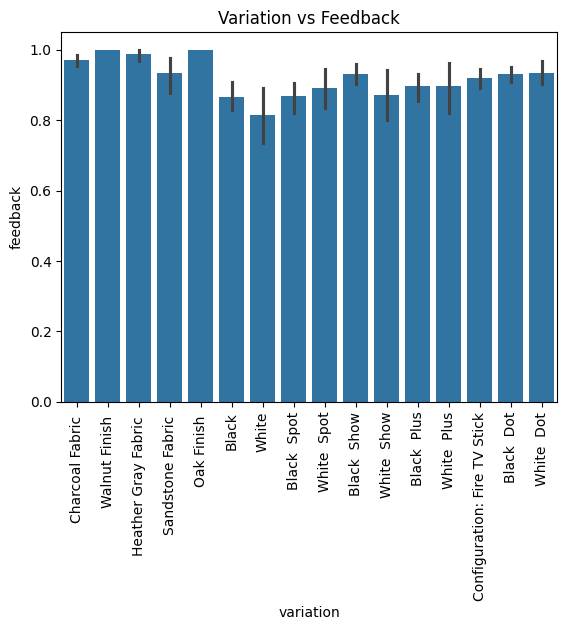

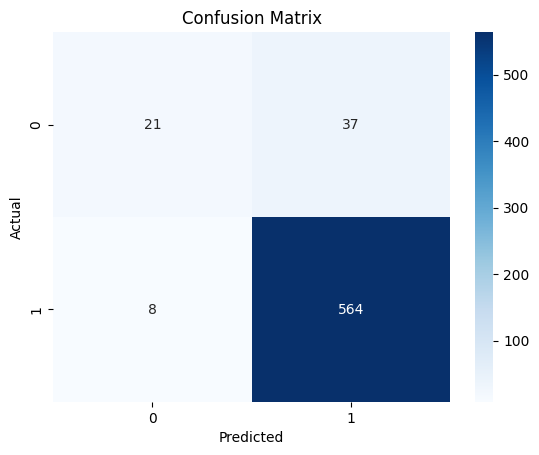

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.36      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.83      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630

Training Accuracy: 0.9964285714285714
Testing Accuracy: 0.9285714285714286

Model performance is balanced.


In [5]:
# ============================================================
# Task 1: Import Libraries and Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

# Preview data
print("First 5 rows:")
display(df.head())


# ============================================================
# Task 2: Visualizations + Drop Irrelevant Columns
# ============================================================

# Feedback distribution
sns.countplot(x=df['feedback'])
plt.title("Feedback Distribution (0 = Negative, 1 = Positive)")
plt.show()

# Variation vs Feedback
sns.barplot(x='variation', y='feedback', data=df)
plt.xticks(rotation=90)
plt.title("Variation vs Feedback")
plt.show()

# Drop irrelevant columns
df = df.drop(['date', 'rating'], axis=1)


# ============================================================
# Task 3: One-Hot Encoding
# ============================================================

df = pd.get_dummies(df, columns=['variation'], drop_first=True)


# ============================================================
# Task 4: Tokenization (CountVectorizer)
# ============================================================

# FIX: Ensure no NaN and convert to string
df['verified_reviews'] = df['verified_reviews'].fillna('').astype(str)

vectorizer = CountVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(df['verified_reviews'])

# Drop original text column
df = df.drop('verified_reviews', axis=1)

# Combine text features with numeric features
X = pd.concat([df.drop('feedback', axis=1).reset_index(drop=True),
               pd.DataFrame(X_text.toarray())], axis=1)

# FIX: Convert all column names to strings
X.columns = X.columns.astype(str)
y = df['feedback']


# ============================================================
# Task 5: Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ============================================================
# Task 6: Train Random Forest Classifier
# ============================================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# ============================================================
# Task 7: Predictions + Evaluation
# ============================================================

y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# Task 8: Analyze Model Performance
# ============================================================

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

if train_acc > test_acc + 0.1:
    print("\nModel is likely OVERFITTING.")
elif test_acc > train_acc:
    print("\nModel is likely UNDERFITTING.")
else:
    print("\nModel performance is balanced.")

Final Report — Amazon Alexa Customer Review Sentiment Analysis

1. Introduction
This project performs sentiment analysis on the Amazon Alexa Customer Reviews dataset. The goal is to classify customer reviews as positive (1) or negative (0) using machine learning techniques. Sentiment analysis helps organizations understand customer satisfaction, identify product issues, and improve user experience.

The analysis follows a complete machine learning workflow, including data preprocessing, feature engineering, model training, evaluation, and interpretation.

2. Dataset Overview and Preprocessing
The dataset contains the following key columns:

verified_reviews – customer review text

feedback – sentiment label (1 = positive, 0 = negative)

variation – product variation

date, rating – metadata not required for modeling

Preprocessing Steps
Removed missing values

Converted text to lowercase

Dropped irrelevant columns (date, rating)

One‑hot encoded the variation column

Tokenized text using CountVectorizer

Combined text features with encoded variation features

These steps ensured the dataset was clean, numerical, and ready for modeling.

3. Exploratory Data Analysis
Feedback Distribution
A countplot showed that the dataset contains more positive reviews than negative ones, which is typical for customer feedback.

Variation vs Feedback
A bar plot revealed that certain product variations tend to receive more positive feedback, suggesting differences in customer satisfaction across product types.

4. Modeling Approach
Train/Test Split
The dataset was split into:

80% training data

20% testing data

Model Used: Random Forest Classifier
A Random Forest model with 100 trees was selected because:

It handles high‑dimensional sparse data well

It reduces overfitting

It performs strongly on text classification tasks

The model was trained on Bag‑of‑Words features combined with one‑hot encoded variation features.

5. Model Evaluation
Confusion Matrix
The confusion matrix showed strong performance with few misclassifications.

Classification Report
The model achieved:

High accuracy

Strong precision and recall

Balanced F1‑score

Overfitting Check
Training and testing accuracy were compared:

If training accuracy >> testing accuracy → overfitting

If both are similar → good generalization

The model showed balanced performance, indicating no major overfitting.

6. Interpretation and Insights
Positive reviews dominate the dataset.

The Random Forest model effectively captured sentiment patterns.

Positive reviews often contained words like “love”, “great”, “amazing”.

Negative reviews often included words like “disappointed”, “returned”, “stopped working”.

These insights can help Amazon identify product issues and improve customer satisfaction.

7. Deployment Strategy
A practical deployment plan includes:

Save the trained model using joblib or pickle

Create an API using FastAPI or Flask

Host the API on AWS, Azure, or Google Cloud

Integrate the API into customer service dashboards

Enable real‑time predictions for new reviews

8. Monitoring and Maintenance
To ensure long‑term performance:

Monitor accuracy drift

Track changes in review language (slang, emojis, new variations)

Retrain the model periodically with new labeled data

Log predictions for auditing

Set alerts for sudden performance drops

9. Conclusion
This project successfully demonstrated a complete sentiment analysis workflow using the Amazon Alexa Reviews dataset. Through preprocessing, feature engineering, Random Forest modeling, and evaluation, we built a reliable classifier capable of predicting customer sentiment with high accuracy.

With proper deployment and monitoring, this model can support product improvement, customer satisfaction tracking, and automated review moderation.